# Flight Delay Case
## BI Project
### Loading Libraries that will be useful in our project

In [1]:
#For Data loading and manipulation
import pandas as pd
import numpy as np

# For Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# For Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

# For the Machine Learning Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Treating imbalanced data
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler


### Loading and inspecting the data

In [2]:


# Load the dataset
df = pd.read_csv("D:\\MSC_BI\\BI\\Project\\August\\Data\\flights_sample_3m.csv")

# Display the first few rows
df.head(10)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN
5,2019-07-31,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,665,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",...,0.0,60.0,54.0,36.0,181.0,141.0,0.0,0.0,0.0,0.0
6,2023-06-11,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2134,DCA,"Washington, DC",BOS,"Boston, MA",...,0.0,109.0,89.0,58.0,399.0,NaN,NaN,NaN,NaN,NaN
7,2019-07-08,Republic Airline,Republic Airline: YX,YX,20452,4464,HSV,"Huntsville, AL",DCA,"Washington, DC",...,0.0,122.0,151.0,88.0,613.0,0.0,0.0,23.0,0.0,0.0
8,2023-02-12,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,590,IAH,"Houston, TX",LAX,"Los Angeles, CA",...,0.0,227.0,219.0,200.0,1379.0,NaN,NaN,NaN,NaN,NaN
9,2020-08-22,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,223,SEA,"Seattle, WA",FAI,"Fairbanks, AK",...,0.0,210.0,220.0,198.0,1533.0,NaN,NaN,NaN,NaN,NaN


### Data Preprocessing

In [3]:
import pandas as pd


# Convert a column to datetime format
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='%Y-%m-%d', errors='coerce')

# Check the updated data types
print(df.dtypes)


FL_DATE                    datetime64[ns]
AIRLINE                            object
AIRLINE_DOT                        object
AIRLINE_CODE                       object
DOT_CODE                            int64
FL_NUMBER                           int64
ORIGIN                             object
ORIGIN_CITY                        object
DEST                               object
DEST_CITY                          object
CRS_DEP_TIME                        int64
DEP_TIME                          float64
DEP_DELAY                         float64
TAXI_OUT                          float64
WHEELS_OFF                        float64
WHEELS_ON                         float64
TAXI_IN                           float64
CRS_ARR_TIME                        int64
ARR_TIME                          float64
ARR_DELAY                         float64
CANCELLED                         float64
CANCELLATION_CODE                  object
DIVERTED                          float64
CRS_ELAPSED_TIME                  

In [4]:
import pandas as pd



# Get day number (Monday=0, Sunday=6)
df['day_number'] = df['FL_DATE'].dt.weekday
# Create a month number column
df['month'] = df['FL_DATE'].dt.month
df=df.drop(columns='FL_DATE')

df.head(10)


,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,...,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,day_number,month
0,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,...,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN,2,1
1,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,...,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN,5,11
2,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,...,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN,4,7
3,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,...,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,0,3
4,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,...,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN,6,2
5,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,665,DAL,"Dallas, TX",OKC,"Oklahoma City, OK",1010,...,54.0,36.0,181.0,141.0,0.0,0.0,0.0,0.0,2,7
6,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2134,DCA,"Washington, DC",BOS,"Boston, MA",1010,...,89.0,58.0,399.0,NaN,NaN,NaN,NaN,NaN,6,6
7,Republic Airline,Republic Airline: YX,YX,20452,4464,HSV,"Huntsville, AL",DCA,"Washington, DC",1643,...,151.0,88.0,613.0,0.0,0.0,23.0,0.0,0.0,0,7
8,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,590,IAH,"Houston, TX",LAX,"Los Angeles, CA",530,...,219.0,200.0,1379.0,NaN,NaN,NaN,NaN,NaN,6,2
9,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,223,SEA,"Seattle, WA",FAI,"Fairbanks, AK",2125,...,220.0,198.0,1533.0,NaN,NaN,NaN,NaN,NaN,5,8


In [5]:
# convert day number and month to cyclical
import numpy as np

# Day of week (1–7)
df['day_sin'] = np.sin(2 * np.pi * df['day_number']/7)
df['day_cos'] = np.cos(2 * np.pi * df['day_number']/7)

# Month (1–12)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)


### Considering 15 min or more is delay, create a new column of delay status

In [6]:
# Create binary classification column: 1 = Delayed, 0 = Not Delayed
# compute delay status assuming a delay flight is a flight delayed 15 minutes or more 
df['delay_status'] = np.where(df['ARR_DELAY'] > 15, 1, 0)
df.head(10)
print(df.dtypes)

AIRLINE                     object
AIRLINE_DOT                 object
AIRLINE_CODE                object
DOT_CODE                     int64
FL_NUMBER                    int64
ORIGIN                      object
ORIGIN_CITY                 object
DEST                        object
DEST_CITY                   object
CRS_DEP_TIME                 int64
DEP_TIME                   float64
DEP_DELAY                  float64
TAXI_OUT                   float64
WHEELS_OFF                 float64
WHEELS_ON                  float64
TAXI_IN                    float64
CRS_ARR_TIME                 int64
ARR_TIME                   float64
ARR_DELAY                  float64
CANCELLED                  float64
CANCELLATION_CODE           object
DIVERTED                   float64
CRS_ELAPSED_TIME           float64
ELAPSED_TIME               float64
AIR_TIME                   float64
DISTANCE                   float64
DELAY_DUE_CARRIER          float64
DELAY_DUE_WEATHER          float64
DELAY_DUE_NAS       

In [7]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing Values per Column:\n", missing_values)

# Percentage of missing values
missing_percentage = (df.isnull().mean() * 100).round(2)
print("\nPercentage of Missing Values:\n", missing_percentage[missing_percentage > 0])


Missing Values per Column:
 CANCELLATION_CODE          2920860
DELAY_DUE_WEATHER          2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_CARRIER          2466137
AIR_TIME                     86198
ELAPSED_TIME                 86198
ARR_DELAY                    86198
TAXI_IN                      79944
WHEELS_ON                    79944
ARR_TIME                     79942
TAXI_OUT                     78806
WHEELS_OFF                   78806
DEP_DELAY                    77644
DEP_TIME                     77615
CRS_ELAPSED_TIME                14
dtype: int64

Percentage of Missing Values:
 DEP_TIME                    2.59
DEP_DELAY                   2.59
TAXI_OUT                    2.63
WHEELS_OFF                  2.63
WHEELS_ON                   2.66
TAXI_IN                     2.66
ARR_TIME                    2.66
ARR_DELAY                   2.87
CANCELLATION_CODE          97.36
ELAPSED_TIME                2.87
AI

In [8]:
# Drop Cancelled Coloumn
df = df.drop(df[df.CANCELLED == True].index)

In [9]:
# Drop Diverted coloumn 
df = df.drop(df[df.DIVERTED == True].index)

In [10]:
# Drop columns with high missing values
columns_to_drop = ['CANCELLATION_CODE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 
                   'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']
df = df.drop(columns=columns_to_drop)

In [11]:
# Remove rows with at least one missing value
df = df.dropna()

print("Original shape:", df.shape)
print("After removing rows with missing values:", df.shape)


Original shape: (2913802, 32)
After removing rows with missing values: (2913802, 32)


In [12]:
import pandas as pd
import numpy as np

# Function to convert HHMM format to fractional hour of day
def hhmm_to_hour(val):
    if pd.isna(val):  # handle NaN
        return np.nan
    val = int(val)
    hour = val // 100
    minute = val % 100
    return hour+minute/60
# List of time columns in HHMM format
time_columns = ['CRS_DEP_TIME', 'DEP_TIME', 'ARR_TIME', 'CRS_ARR_TIME']

# Apply conversion and create new columns
for col in time_columns:
    if col in df.columns:
        df[col + '_HOUR'] = df[col].apply(hhmm_to_hour)

# Check results
print(df[[col + '_HOUR' for col in time_columns if col in df.columns]].head())


   CRS_DEP_TIME_HOUR  DEP_TIME_HOUR  ARR_TIME_HOUR  CRS_ARR_TIME_HOUR
0          11.916667      11.850000      14.783333          15.016667
1          21.333333      21.233333      23.166667          23.250000
2           9.900000      10.000000      12.866667          12.866667
3          16.150000      16.133333      18.883333          18.483333
4          18.666667      18.633333      20.666667          20.683333


In [13]:
print(df.dtypes)

AIRLINE               object
AIRLINE_DOT           object
AIRLINE_CODE          object
DOT_CODE               int64
FL_NUMBER              int64
ORIGIN                object
ORIGIN_CITY           object
DEST                  object
DEST_CITY             object
CRS_DEP_TIME           int64
DEP_TIME             float64
DEP_DELAY            float64
TAXI_OUT             float64
WHEELS_OFF           float64
WHEELS_ON            float64
TAXI_IN              float64
CRS_ARR_TIME           int64
ARR_TIME             float64
ARR_DELAY            float64
CANCELLED            float64
DIVERTED             float64
CRS_ELAPSED_TIME     float64
ELAPSED_TIME         float64
AIR_TIME             float64
DISTANCE             float64
day_number             int32
month                  int32
day_sin              float64
day_cos              float64
month_sin            float64
month_cos            float64
delay_status           int64
CRS_DEP_TIME_HOUR    float64
DEP_TIME_HOUR        float64
ARR_TIME_HOUR 

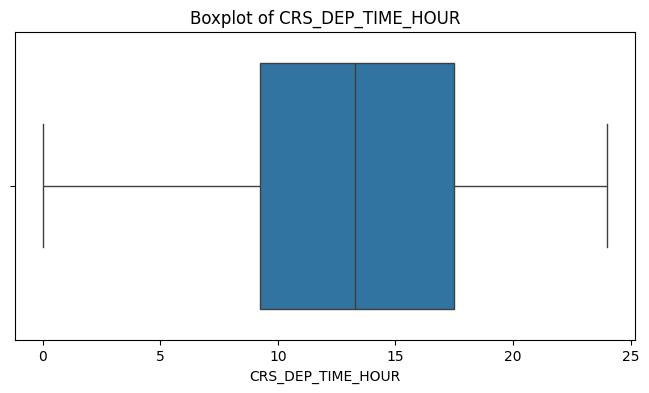

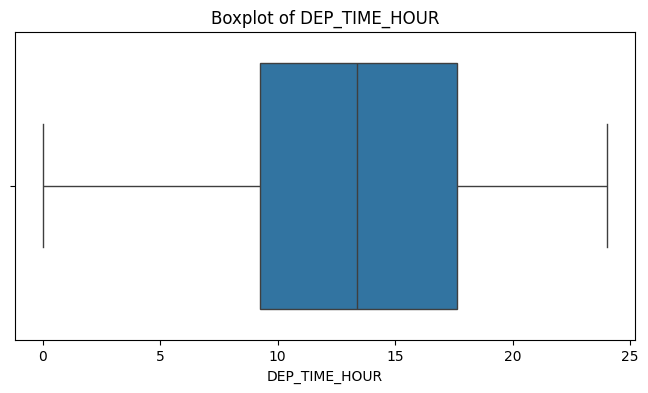

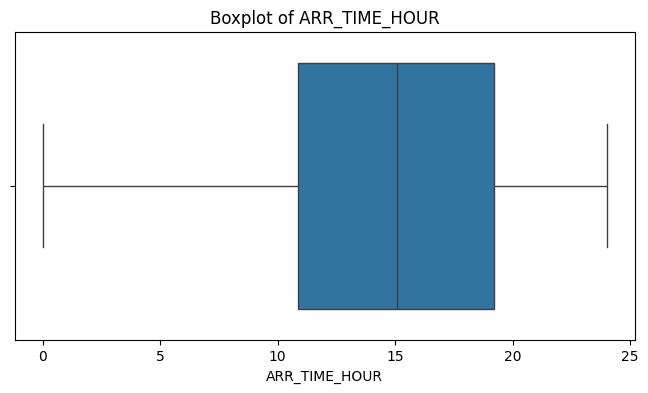

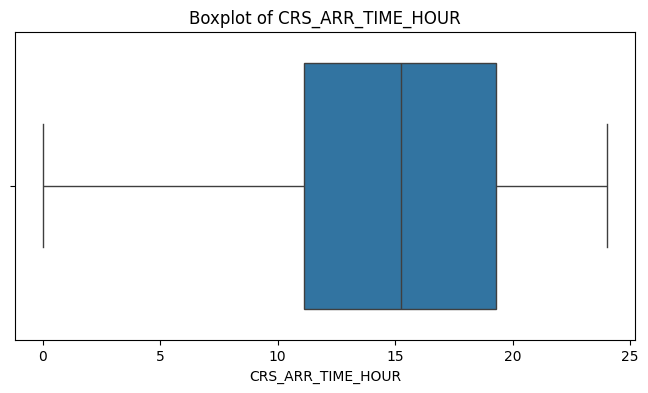

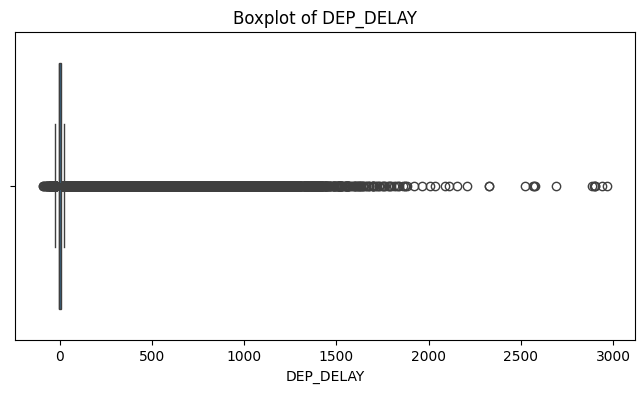

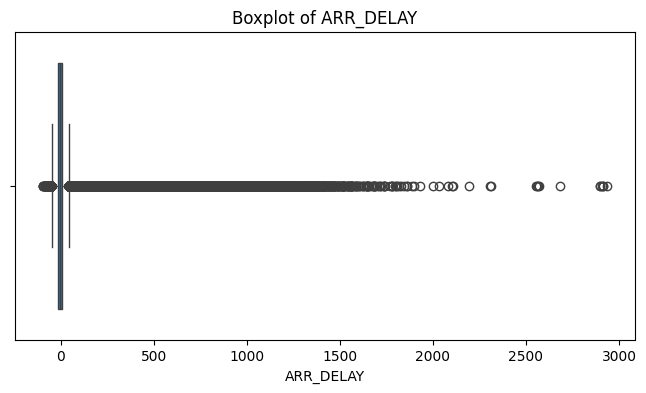

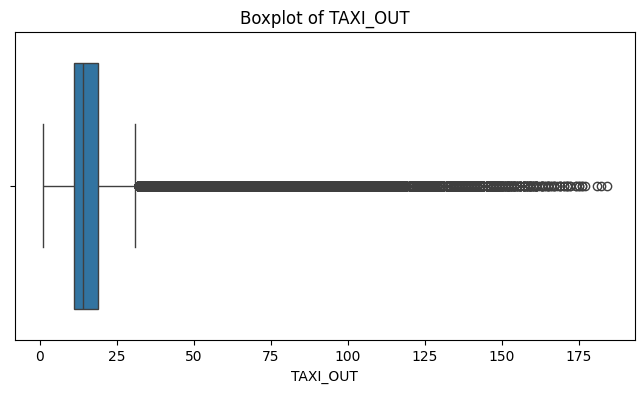

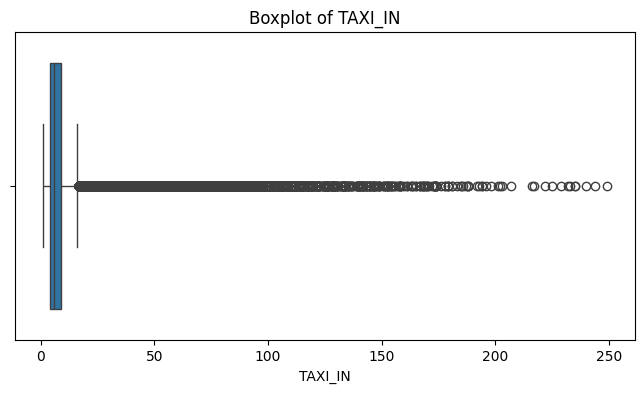

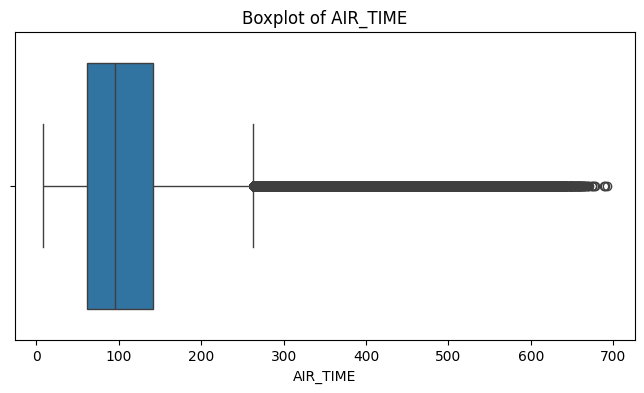

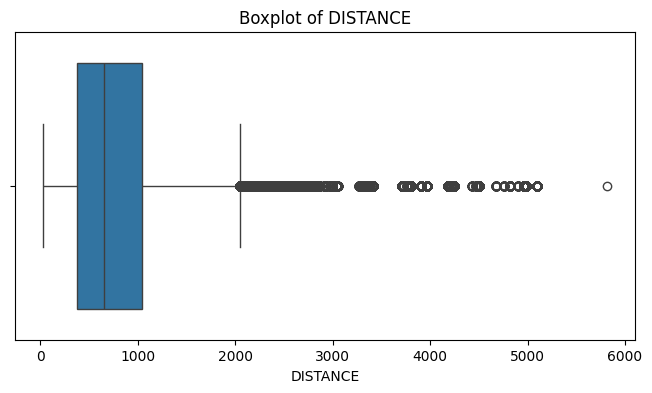

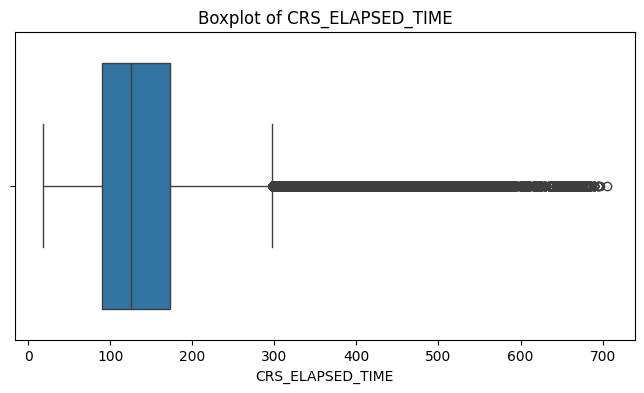

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: Visualize outliers for a few key numeric features
num_features = ['CRS_DEP_TIME_HOUR', 'DEP_TIME_HOUR', 'ARR_TIME_HOUR', 'CRS_ARR_TIME_HOUR','DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME', 'DISTANCE', 'CRS_ELAPSED_TIME']

for col in num_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


### Ploting the correlation matrix 

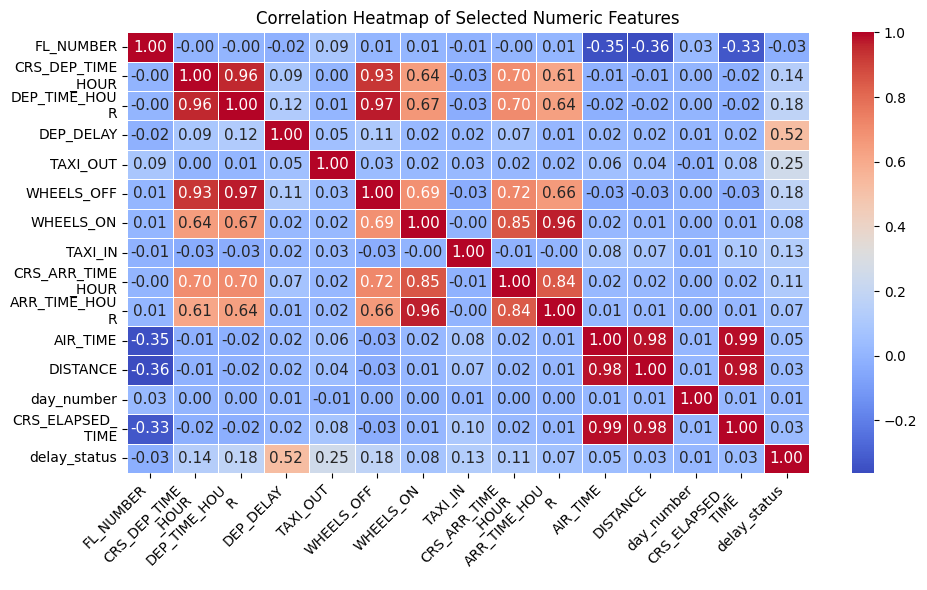

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only numeric features for correlation
numeric_cols = ['FL_NUMBER', 'CRS_DEP_TIME_HOUR', 'DEP_TIME_HOUR', 'DEP_DELAY', 'TAXI_OUT',
                'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME_HOUR', 'ARR_TIME_HOUR', 'AIR_TIME', 'DISTANCE','day_number', 'CRS_ELAPSED_TIME']

# Compute correlation matrix
corr_matrix = df[numeric_cols + ['delay_status']].corr()

import textwrap

def wrap_labels(labels, width=12):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

corr_matrix.columns = wrap_labels(corr_matrix.columns)
corr_matrix.index = wrap_labels(corr_matrix.index)


# Plot the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",annot_kws={"size": 11}, linewidths=0.5)

# Rotate the axis labels
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.tight_layout()
plt.show()


### Select features and define target

In [ ]:


# We'll keep these numerical features + already encoded categorical columns
selected_columns = [
   'FL_NUMBER', 'month_sin','month_cos', 'CRS_DEP_TIME_HOUR', 'CRS_ARR_TIME_HOUR', 'CRS_ELAPSED_TIME', 'DISTANCE','day_sin', 'day_cos', 'AIRLINE_CODE', 'ORIGIN', 'DEST']


# Train-Test Split + Set Models
# 1. Logistic Regression

In [16]:

# Factorize categoricals
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col], _ = pd.factorize(df[col])

# Fill missing values
df = df.fillna(0)  # simple fill, or use median/mode as above

# Train-test split
X = df[selected_columns]  # replace TARGET_COLUMN with your target
y = df['delay_status']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8231556332698997
F1 Score: 0.0
ROC-AUC: 0.6133025042766628

Classification Report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90    479703
           1       0.00      0.00      0.00    103058

    accuracy                           0.82    582761
   macro avg       0.41      0.50      0.45    582761
weighted avg       0.68      0.82      0.74    582761


Confusion Matrix:
 [[479703      0]
 [103058      0]]


c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## 1.2 Visulizing Logistic Regression Model

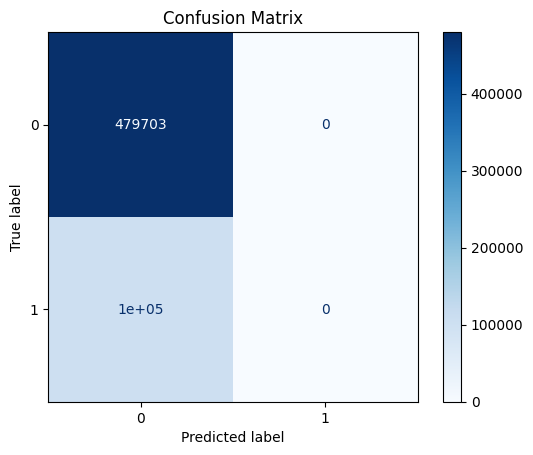

In [17]:
#5:Confusion Matrix & ROC Curve
#To  help us see the kinds of mistakes our model makes.
from sklearn.metrics import ConfusionMatrixDisplay
%matplotlib inline

#i. Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


### 2. Treating imbalanced data


### 2.1 Undersampling (RUS)

Counter({0: 515289, 1: 515289})
Class distribution after undersampling: Counter({1: 412231, 0: 412231})
Counter({1: 103058, 0: 103058})
Logistic Regression Accuracy: 0.5897795416173417

Logistic Regression Confusion Matrix:
 [[59152 43906]
 [40647 62411]]

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0      0.593     0.574     0.583    103058
           1      0.587     0.606     0.596    103058

    accuracy                          0.590    206116
   macro avg      0.590     0.590     0.590    206116
weighted avg      0.590     0.590     0.590    206116

F1 Score: 0.596164776119403
ROC-AUC: 0.6165195286737404


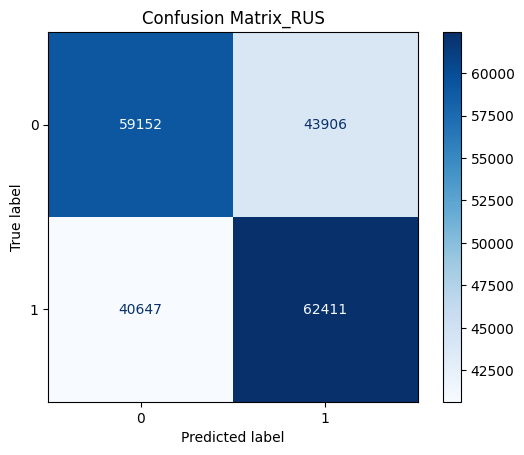

In [18]:

# Create the undersampler
undersampler = RandomUnderSampler(random_state=42)

# Apply undersampling only to training data (not test data!)
X_new2, y_new2 = undersampler.fit_resample(X, y)
X_train_under, X_test3, y_train_under, y_test3 = train_test_split(X_new2, y_new2, test_size=0.2, random_state=42, stratify=y_new2)

# Check class distribution
from collections import Counter
print(Counter(y_new2))
print("Class distribution after undersampling:", Counter(y_train_under))
print(Counter(y_test3))

# Create the model
log_reg_under = LogisticRegression(solver='liblinear', random_state=42)

# Fit the model
log_reg_under.fit(X_train_under, y_train_under)

# Predict on test set
y_pred = log_reg_under.predict(X_test3)

# Evaluate performance
accuracy = accuracy_score(y_test3, y_pred)
conf_matrix = confusion_matrix(y_test3, y_pred)
class_report = classification_report(y_test3, y_pred, digits=3)

# Print results
print("Logistic Regression Accuracy:", accuracy)
print("\nLogistic Regression Confusion Matrix:\n", conf_matrix)
print("\nLogistic Regression Classification Report:\n", class_report)

f13 = f1_score(y_test3, y_pred)
roc_auc3 = roc_auc_score(y_test3, log_reg_under.predict_proba(X_test3)[:, 1])

print("F1 Score:", f13)
print("ROC-AUC:", roc_auc3)

ConfusionMatrixDisplay.from_estimator(log_reg_under, X_test3, y_test3, cmap='Blues')
plt.title("Confusion Matrix_RUS")
plt.show()

# 2. Random Forest

In [19]:
##**Now using a different model: Random Forest**
## training the model with under sampled data



# Sample 100,000 rows randomly
X_sample = X_train_under.sample(n=100000, random_state=42)
y_sample = y_train_under.loc[X_sample.index]

# Re-train Random Forest on this smaller sample
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_under, y_train_under)




RandomForestClassifier(random_state=42)

In [20]:
#2. Predict and Evaluate the model
# Predict on the full test set
y_pred_rf = rf_model.predict(X_test3)
y_prob_rf = rf_model.predict_proba(X_test3)[:, 1]  # Needed for ROC-AUC

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

accuracy_rf = accuracy_score(y_test3, y_pred_rf)
f1_rf = f1_score(y_test3, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test3, y_prob_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest F1 Score:", f1_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)


Random Forest Accuracy: 0.6007005763744687
Random Forest F1 Score: 0.5963332450487037
Random Forest ROC-AUC: 0.6378384270228544


In [21]:
#Evaluation Metrics
print("Classification Report – Random Forest:")
print(classification_report(y_test3, y_pred_rf, digits=3))



Classification Report – Random Forest:
              precision    recall  f1-score   support

           0      0.599     0.612     0.605    103058
           1      0.603     0.590     0.596    103058

    accuracy                          0.601    206116
   macro avg      0.601     0.601     0.601    206116
weighted avg      0.601     0.601     0.601    206116



## 2.1 Visualizing RF Model

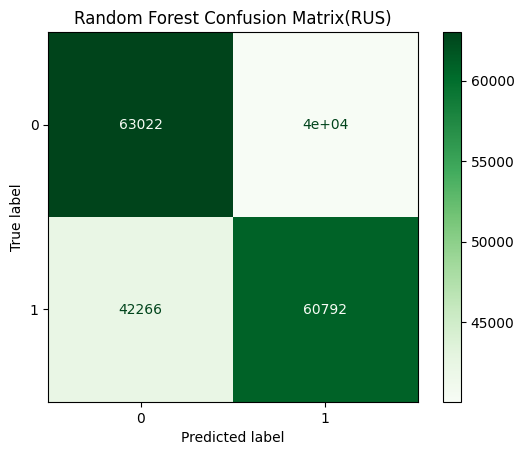

In [22]:
#3.Plot the Confusion Matrix and ROC Curve

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test3, y_test3, cmap='Greens')
plt.title("Random Forest Confusion Matrix(RUS)")
plt.show()




C:\Users\mepas\AppData\Local\Temp\ipykernel_10636\3255550494.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')


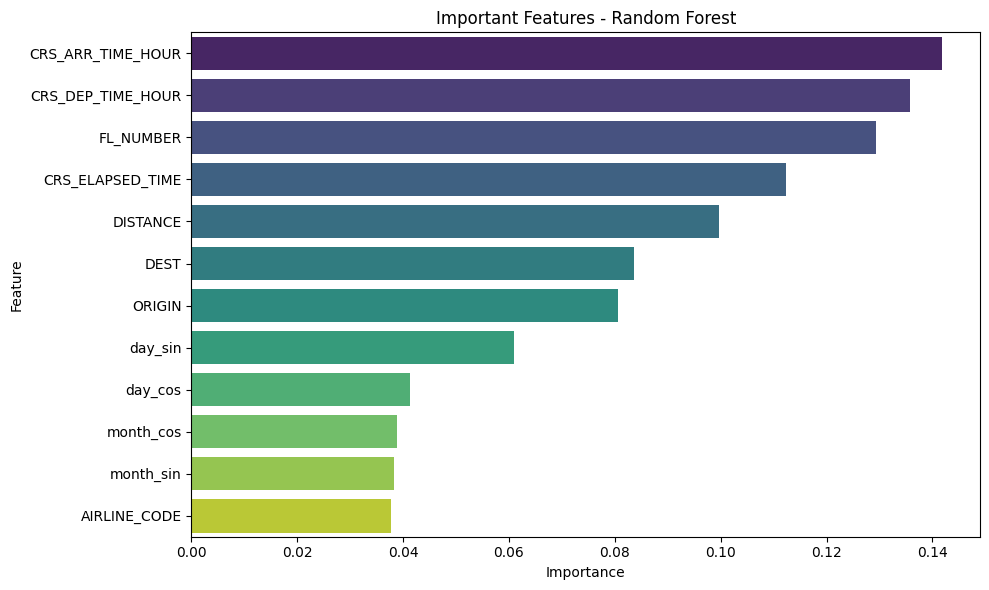

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from your trained model
importances = rf_model.feature_importances_

# Match importances with feature names
feature_names = X_train_under.columns
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Important Features - Random Forest')
plt.tight_layout()
plt.show()


C:\Users\mepas\AppData\Local\Temp\ipykernel_31084\828612868.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_counts, x='AIRLINE', y='delay_status', palette='mako')


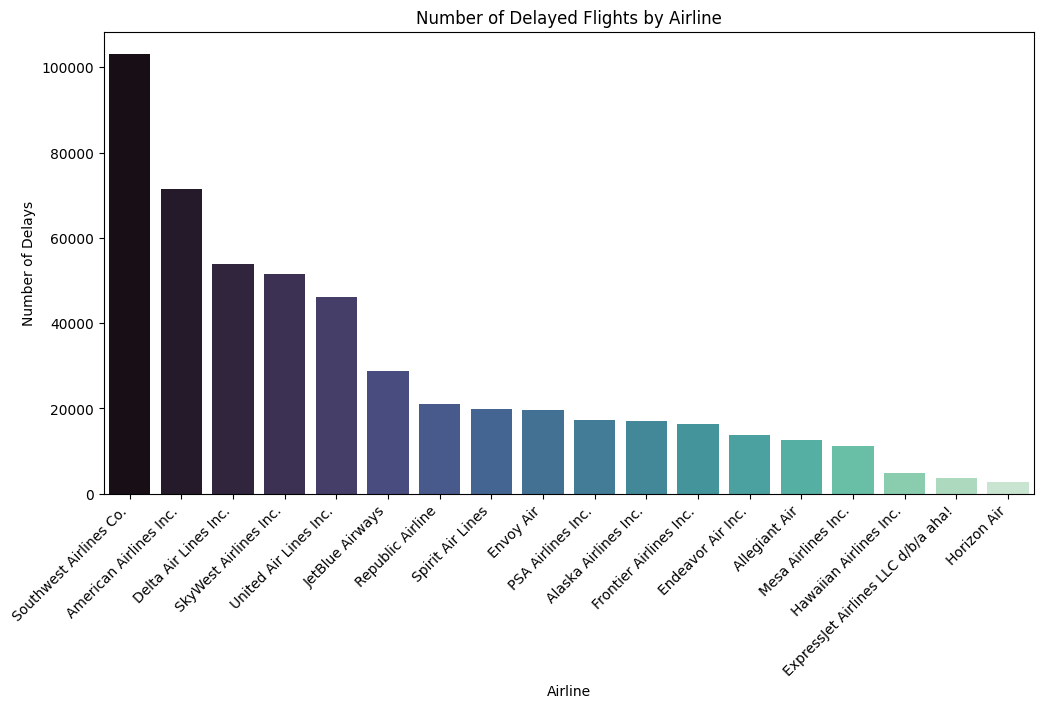

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Count number of delays by airline
delay_counts = df.groupby('AIRLINE')['delay_status'].sum().reset_index()

# ✅ Sort by delay count (descending)
delay_counts = delay_counts.sort_values(by='delay_status', ascending=False)

# ✅ Plot
plt.figure(figsize=(12,6))
sns.barplot(data=delay_counts, x='AIRLINE', y='delay_status', palette='mako')
plt.title('Number of Delayed Flights by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45, ha='right')
plt.show()


C:\Users\mepas\AppData\Local\Temp\ipykernel_31084\1574295118.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_counts, x='month', y='delay_status', palette='mako')


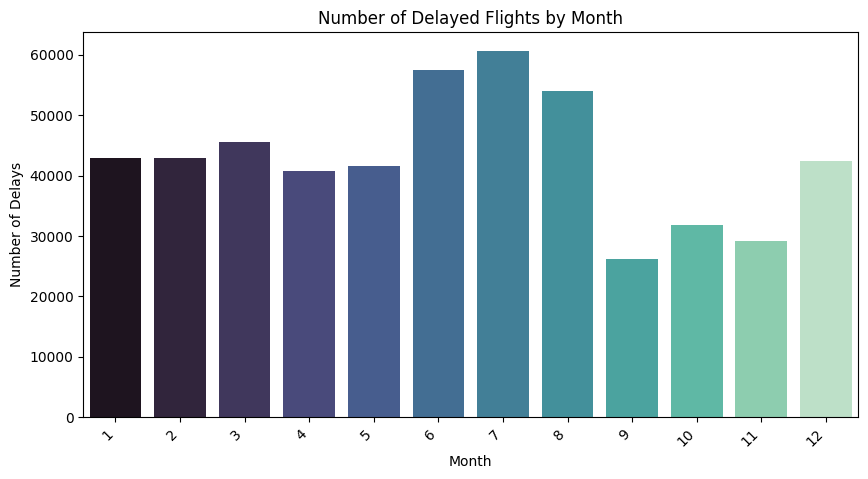

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Count number of delays by month
delay_counts = df.groupby('month')['delay_status'].sum().reset_index()

# ✅ Plot
plt.figure(figsize=(10,5))
sns.barplot(data=delay_counts, x='month', y='delay_status', palette='mako')
plt.title('Number of Delayed Flights by Month')
plt.xlabel('Month')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45, ha='right')
plt.show()


C:\Users\mepas\AppData\Local\Temp\ipykernel_31084\66396240.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_counts, x='day_number', y='delay_status', palette='mako')


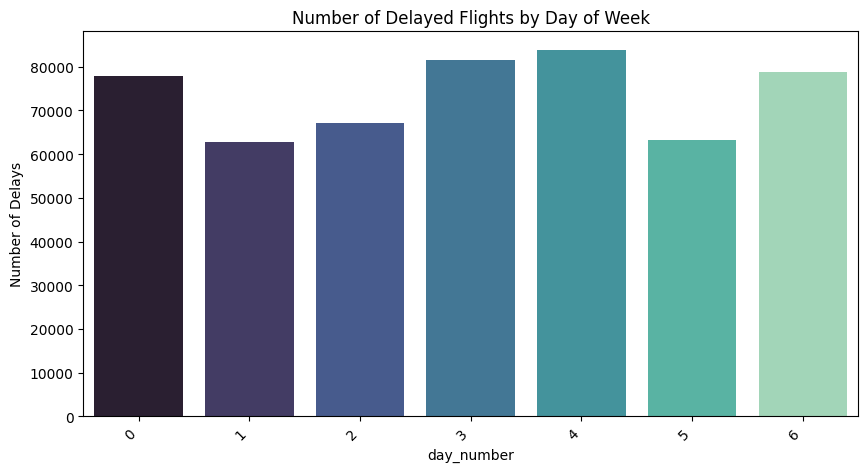

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Count number of delays by month
delay_counts = df.groupby('day_number')['delay_status'].sum().reset_index()

# ✅ Plot
plt.figure(figsize=(10,5))
sns.barplot(data=delay_counts, x='day_number', y='delay_status', palette='mako')
plt.title('Number of Delayed Flights by Day of Week')
plt.xlabel('day_number')
plt.ylabel('Number of Delays')
plt.xticks(rotation=45, ha='right')
plt.show()


C:\Users\mepas\AppData\Local\Temp\ipykernel_31084\3052860587.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_counts, x='day_number', y='delay_status', palette='mako')


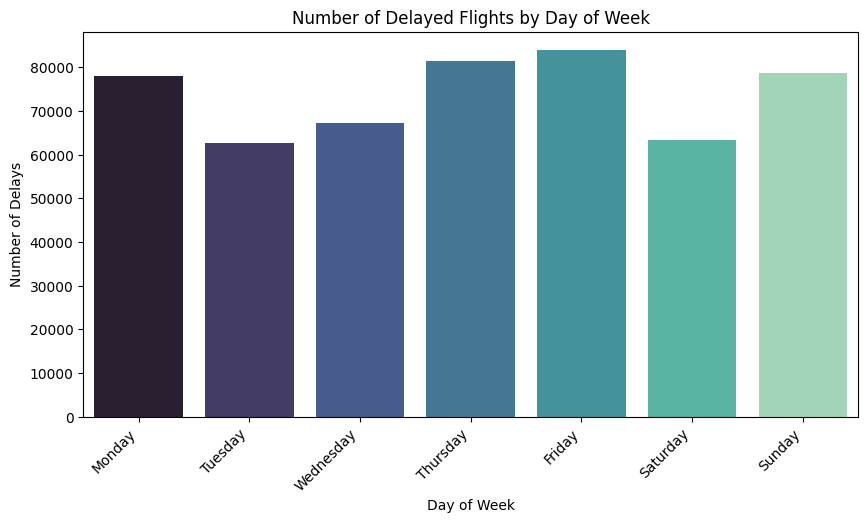

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Count number of delays by day_number
delay_counts = df.groupby('day_number')['delay_status'].sum().reset_index()

# ✅ Plot
plt.figure(figsize=(10,5))
sns.barplot(data=delay_counts, x='day_number', y='delay_status', palette='mako')

# Map day_number → weekday labels
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.xticks(ticks=range(7), labels=day_labels, rotation=45, ha='right')

plt.title('Number of Delayed Flights by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Delays')
plt.show()


C:\Users\mepas\AppData\Local\Temp\ipykernel_31084\633526874.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_counts, x='Reason', y='Delay Count', palette='viridis')


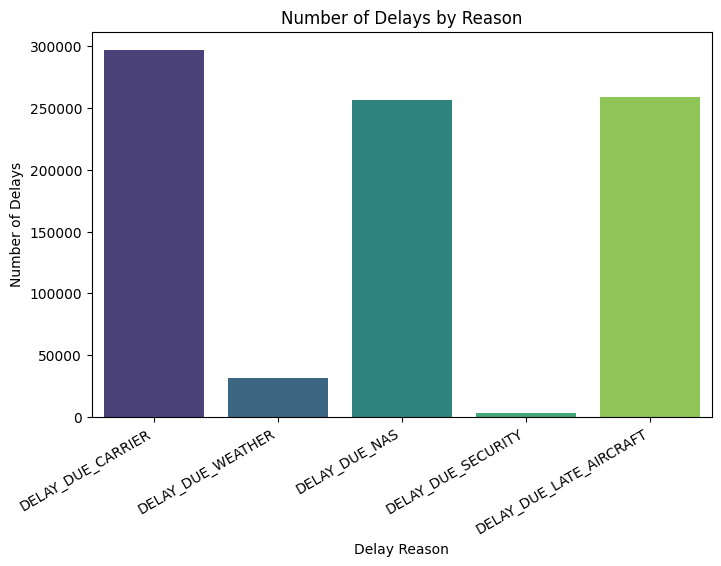

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick only delay reason columns
delay_cols = ['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 
              'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 
              'DELAY_DUE_LATE_AIRCRAFT']

# ✅ Count number of flights delayed for each reason (value > 0)
delay_counts = (df[delay_cols] > 0).sum().reset_index()
delay_counts.columns = ['Reason', 'Delay Count']

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=delay_counts, x='Reason', y='Delay Count', palette='viridis')
plt.title('Number of Delays by Reason')
plt.ylabel('Number of Delays')
plt.xlabel('Delay Reason')
plt.xticks(rotation=30, ha='right')
plt.show()


## 1.1 5-Fold Cross-Validation of the model

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np



# Set up K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_score with accuracy
scores = cross_val_score(log_reg_under,X_new2, y_new2, cv=kf, scoring='accuracy')

# Output results
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-Validation Accuracy Scores: [0.58678123 0.58778552 0.5881688  0.58653179 0.58663368]
Mean Accuracy: 0.5871802025708494
Standard Deviation: 0.0006666390788630393


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np


# Set up K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_score with roc_auc
scores = cross_val_score(log_reg_under,X_new2, y_new2, cv=kf, scoring='roc_auc')

# Output results
print("Cross-Validation ROC_AUC Scores:", scores)
print("Mean ROC_AUC:", scores.mean())
print("Standard Deviation:", scores.std())

c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Cross-Validation ROC_AUC Scores: [0.61181019 0.61396477 0.61604812 0.61363178 0.61229709]
Mean ROC_AUC: 0.6135503910700845
Standard Deviation: 0.0014843201619545454


c:\Users\mepas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np


# Set up K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_score with accuracy
scores = cross_val_score(rf_model,X_new2, y_new2, cv=kf, scoring='accuracy')

# Output results
print("Cross-Validation Accuracy Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-Validation Accuracy Scores: [0.59977877 0.59799336 0.60109356 0.599117   0.59874827]
Mean Accuracy: 0.5993461913342675
Standard Deviation: 0.0010469571365129397


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np


# Set up K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Use cross_val_score with roc_auc
scores = cross_val_score(rf_model,X_new2, y_new2, cv=kf, scoring='roc_auc')

# Output results
print("Cross-Validation ROC_AUC Scores:", scores)
print("Mean ROC_AUC:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-Validation ROC_AUC Scores: [0.63514508 0.63542654 0.6375182  0.63553159 0.63598129]
Mean ROC_AUC: 0.6359205397444423
Standard Deviation: 0.0008429547113138189
